In [29]:
import numpy as np
import matplotlib.pyplot as plt

# données d'entrée : heures d'étude et participation
x = np.array([
    [1.5, 0.1], [2, 0.2], [3, 0.15], [4, 0.1], [2.5, 0.3], [5, 0.2],
    [5.5, 0.5], [6, 0.7], [7, 0.6], [8, 0.75], [6.5, 0.5], [7.5, 0.8]
])

# étiquettes : -1 pour rattrapage, 1 pour réussite
y = np.array([-1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1])

In [30]:
class svm_normale:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=15000):
        # initialisation des hyperparamètres
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, x, y):
        # initialisation des poids (w) et du biais (b)
        n_samples, n_features = x.shape
        self.w = np.zeros(n_features)
        self.b = 0

        # boucle d'optimisation par descente de gradient
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(x):
                # vérification de la condition de marge : y_i * (w.x - b) >= 1
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    # mise à jour avec régularisation uniquement
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # mise à jour avec correction de l'erreur et régularisation
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

# création et entraînement de l'instance du modèle
model = svm_normale()
model.fit(x, y)

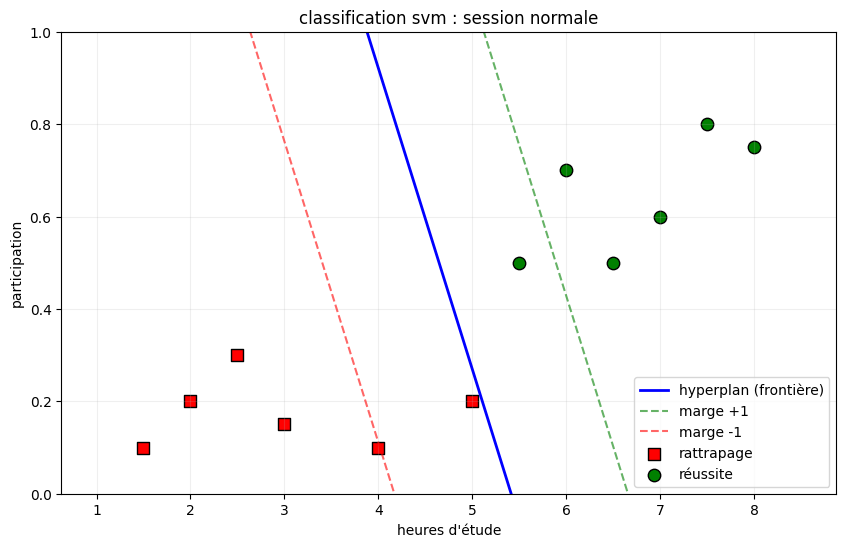

In [31]:
def visualize_normale():
    # fonction pour calculer y à partir de x pour l'hyperplan (w.x - b = v)
    def get_y(x, v): return (-model.w[0] * x + model.b + v) / model.w[1]

    plt.figure(figsize=(10, 6))
    x_range = np.array([1, 8.5])

    # tracé de la frontière de décision (v=0) et des marges (v=1, v=-1)
    plt.plot(x_range, get_y(x_range, 0), 'b', linewidth=2, label='hyperplan (frontière)')
    plt.plot(x_range, get_y(x_range, 1), 'g--', alpha=0.6, label='marge +1')
    plt.plot(x_range, get_y(x_range, -1), 'r--', alpha=0.6, label='marge -1')

    # affichage des points de données classés
    plt.scatter(x[y==-1,0], x[y==-1,1], c='red', marker='s', s=80, label='rattrapage', edgecolors='k')
    plt.scatter(x[y==1,0], x[y==1,1], c='green', marker='o', s=80, label='réussite', edgecolors='k')

    plt.title('classification svm : session normale')
    plt.xlabel('heures d\'étude')
    plt.ylabel('participation')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# appel de la fonction de visualisation
visualize_normale()